# Exploring neoscore Package

In [25]:
from neoscore.common import *

In [114]:
class MusicSheet:
    
    def render_title(self, title=""):
        neoscore.setup()
        Text(ORIGIN, None, title)
        neoscore.render_to_notebook()
        neoscore.shutdown()
        
    def render_notes(self, staves=[], scale="", clef_type="treble", title_text=None, pdf_file_name=None):
        neoscore.setup()
        Text(ORIGIN, None, title_text)
        assert all(isinstance(staff, list) for staff in staves), "Not all staves have notes"
        for staff_index in range(len(staves)):
            notes = staves[staff_index]
            if notes and scale and clef_type:
                staff = Staff((ZERO, Mm((staff_index + 1) * 20)), None, Mm(120))
                clef = Clef(ZERO, staff, clef_type)
                key_signature = KeySignature(ZERO, staff, scale)
                note_index = 5
                for note in notes:
                    Chordrest(Mm(note_index), staff, [note], (1, 4))
                    note_index += 10
        neoscore.render_to_notebook()
        if pdf_file_name:
            neoscore.render_pdf(dpi=300, pdf_path=f"{pdf_file_name}.pdf")
        neoscore.shutdown()

In [115]:
music_sheet = MusicSheet()

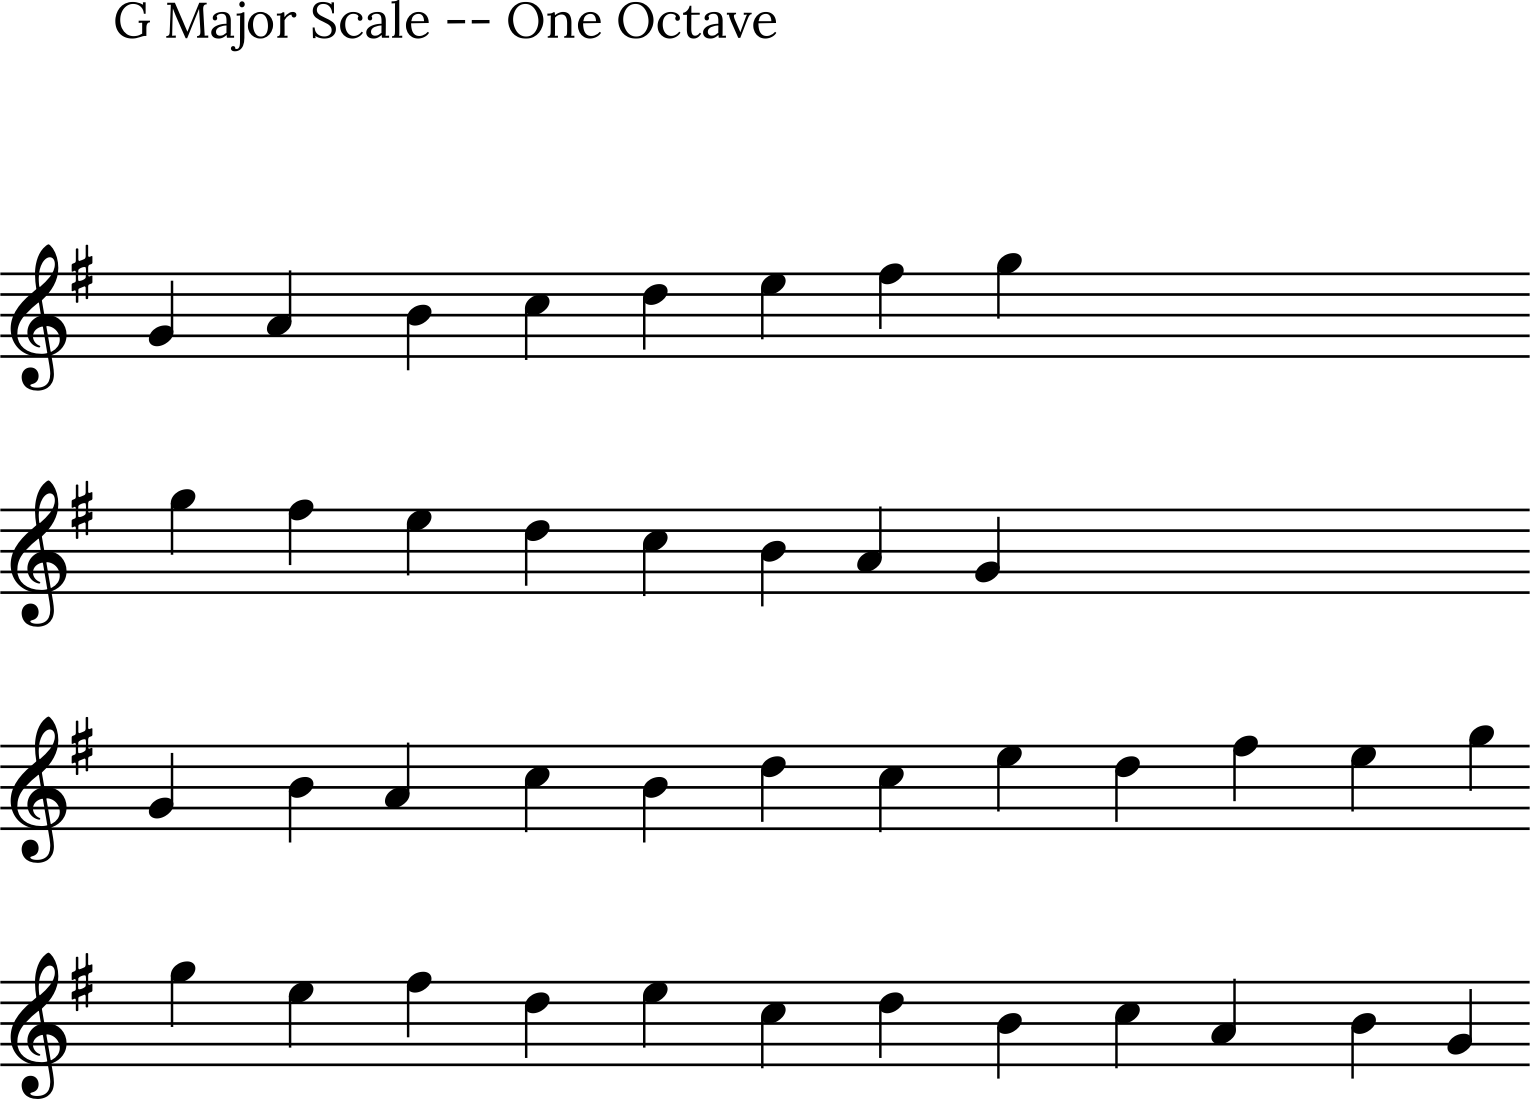

In [116]:
# Render g-scale
g_major_scale_ascending_notes = ["g", "a", "b", "c'", "d'", "e'", "f'", "g'"]
g_major_scale_descending_notes = g_major_scale_ascending_notes[::-1]
g_major_scale_ascending_arpegio_notes = [g_major_scale_ascending_notes[i] for sub_index in [[i, i + 2] for i in range(6)] for i in sub_index]
g_major_scale_descending_arpegio_notes = g_major_scale_ascending_arpegio_notes[::-1]
music_sheet.render_notes(
    staves=[
        g_major_scale_ascending_notes,
        g_major_scale_descending_notes,
        g_major_scale_ascending_arpegio_notes,
        g_major_scale_descending_arpegio_notes
    ],
    scale="g_major",
    clef_type="treble",
    title_text="G Major Scale -- One Octave",
    pdf_file_name="1_g_major_one_octave"
)